In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

import os, sys
os.chdir('..')

from sazz.samplers.AutomaticBoomerangSampler import AutomaticBoomerangSampler
from sazz.models.smoke_test import make_gaussian, make_banana, make_gaussian_mixture, plot_marginals
from sazz.utils.sampling import resample_pdmp_path

In [2]:
def run_test(target, thinning, N_skeleton=50_000, N_resample=50_000,
             refresh_rate=1.0, burnin_frac=0.1, pli_kwargs=None):
    """
    Build sampler, run, resample, return numpy samples.
    """

    sampler = AutomaticBoomerangSampler(
        grad_target=target.grad_target,
        D=target.D,
        refresh_rate=refresh_rate,
        thinning=thinning,
        pli_kwargs=pli_kwargs,
    )
    sampler.preprocess(x_ref=target.x_ref, Sigma_inv=target.Sigma_inv)

    result = sampler.sample(N=N_skeleton, diagnostics=True)

    # Convert to numpy for resampling
    pos_np = result["positions"].cpu().numpy()
    vel_np = result["velocities"].cpu().numpy()
    tim_np = result["times"].cpu().numpy()
    x_ref_np = target.x_ref.cpu().numpy()

    samples = resample_pdmp_path(pos_np, vel_np, tim_np, x_ref_np,
                                 N_resample, burnin_frac=burnin_frac)
    return samples

In [3]:
N_SKELETON = 10_000
N_RESAMPLE = 100_000


TEST 1: Diagonal Gaussian D=5  (matched reference)


Boomerang: 100%|██████████| 10000/10000 [00:10<00:00, 987.39skel/s, t=9938.122]



=== Sampler Diagnostics ===
Total gradient evals  : 468538
Grad evals / skeleton : 46.9

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  no_event  : 15735 events, mean horizon=0.6316
  refresh   :  9999 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000375
Total wall-sec       : 9.65

Simulation time reached: 9938.1216


Boomerang: 100%|██████████| 10000/10000 [00:02<00:00, 4383.55skel/s, t=9943.714]



=== Sampler Diagnostics ===
Total gradient evals  : 49995
Grad evals / skeleton : 5.0

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  no_event  :  9999 events, mean horizon=0.9945
  refresh   :  9999 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000094
Total wall-sec       : 1.89

Simulation time reached: 9943.7145


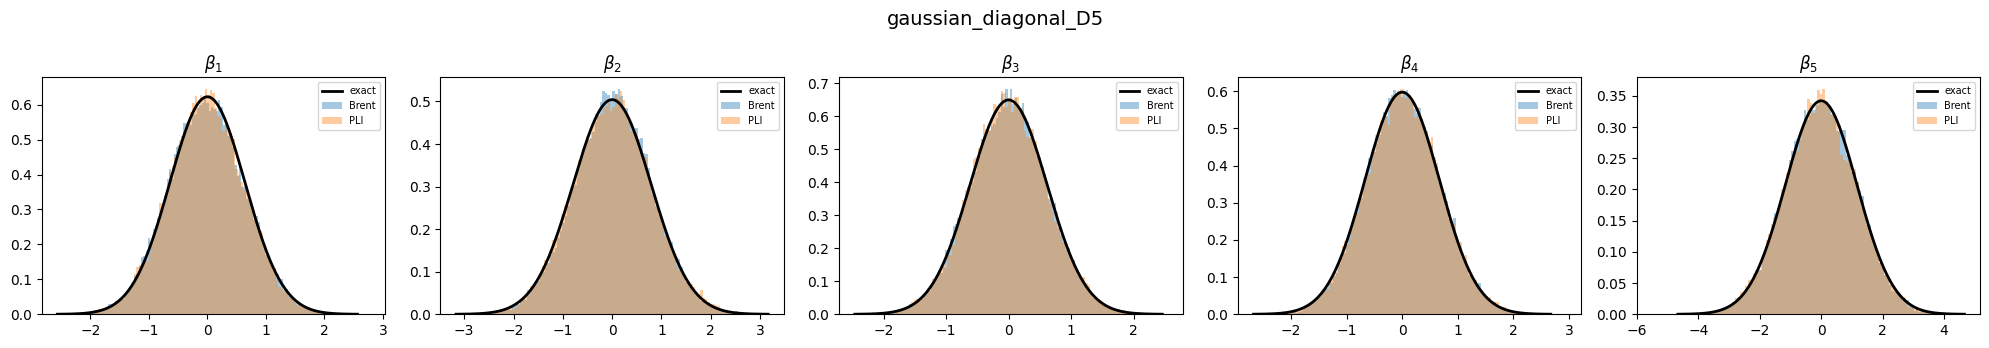

In [4]:
# ── 1. Gaussian (should be trivially correct with matched reference) ──
print("\n" + "="*60)
print("TEST 1: Diagonal Gaussian D=5  (matched reference)")
print("="*60)
target_gauss = make_gaussian(D=5, cov="diagonal")

samp_brent = run_test(target_gauss, thinning="brent",
                        N_skeleton=N_SKELETON, N_resample=N_RESAMPLE)
samp_pli = run_test(target_gauss, thinning="pli",
                    N_skeleton=N_SKELETON, N_resample=N_RESAMPLE)

plot_marginals(target_gauss, {"Brent": samp_brent, "PLI": samp_pli})


TEST 2: AR(1) Gaussian D=5


Boomerang: 100%|██████████| 10000/10000 [00:10<00:00, 926.53skel/s, t=10159.278]



=== Sampler Diagnostics ===
Total gradient evals  : 474565
Grad evals / skeleton : 47.5

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  no_event  : 15978 events, mean horizon=0.6358
  refresh   :  9999 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000396
Total wall-sec       : 10.30

Simulation time reached: 10159.2784


Boomerang: 100%|██████████| 10000/10000 [00:02<00:00, 4618.52skel/s, t=10113.591]



=== Sampler Diagnostics ===
Total gradient evals  : 49995
Grad evals / skeleton : 5.0

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  no_event  :  9999 events, mean horizon=1.0115
  refresh   :  9999 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000089
Total wall-sec       : 1.78

Simulation time reached: 10113.5910


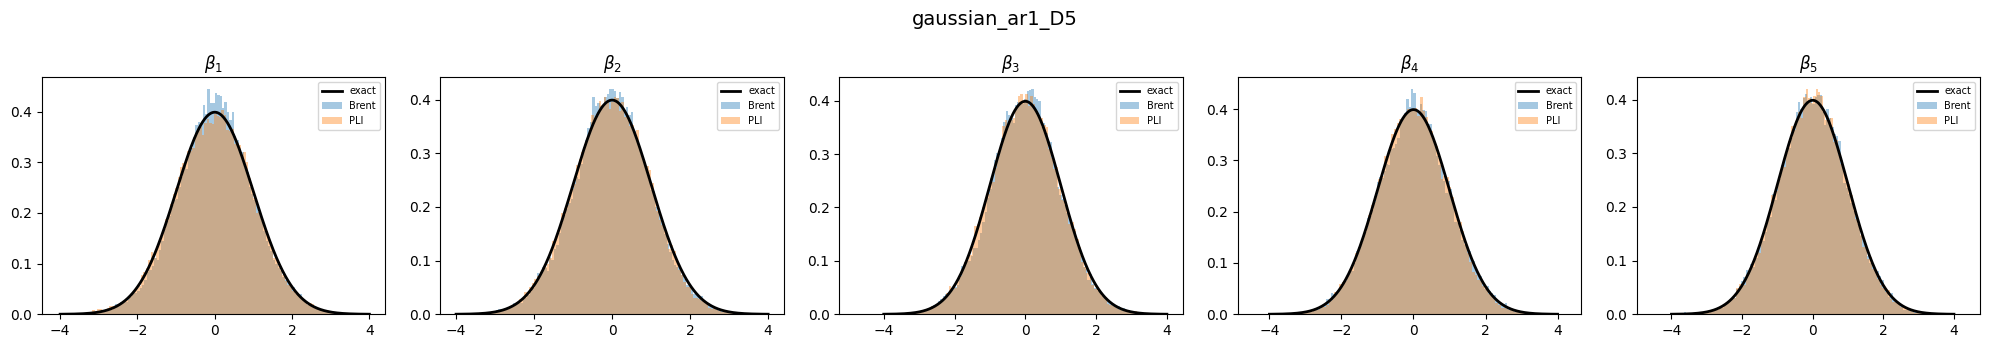

In [5]:
# ── 2. AR(1) Gaussian ──
print("\n" + "="*60)
print("TEST 2: AR(1) Gaussian D=5")
print("="*60)
target_ar = make_gaussian(D=5, cov="ar1")

samp_brent_ar = run_test(target_ar, thinning="brent",
                        N_skeleton=N_SKELETON, N_resample=N_RESAMPLE)

samp_pli_ar = run_test(target_ar, thinning="pli",
                        N_skeleton=N_SKELETON, N_resample=N_RESAMPLE)
plot_marginals(target_ar, {"Brent": samp_brent_ar, "PLI": samp_pli_ar})


TEST 3: Bimodal mixture D=1


Boomerang: 100%|██████████| 10000/10000 [00:24<00:00, 415.03skel/s, t=5124.231]



=== Sampler Diagnostics ===
Total gradient evals  : 651802
Grad evals / skeleton : 65.2

=== Thinning ===
Accept / Reject  : 4789 / 14309

=== Event breakdown ===
  bounce    : 19098 events, mean horizon=0.8187
  no_event  :  6212 events, mean horizon=0.4206
  refresh   :  5210 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000779
Total wall-sec       : 23.77

Simulation time reached: 5124.2308


Boomerang: 100%|██████████| 10000/10000 [00:03<00:00, 3329.51skel/s, t=6313.345]



=== Sampler Diagnostics ===
Total gradient evals  : 62030
Grad evals / skeleton : 6.2

=== Thinning ===
Bound violations : 365
Max ratio        : 1.4991
Proposals/call   : 0.5 mean, 10 max
Accepted bounces : 3630

=== Event breakdown ===
  bounce    :  3630 events, mean horizon=1.5268
  no_event  :  6369 events, mean horizon=0.6788
  refresh   :  6369 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000170
Total wall-sec       : 2.78

Simulation time reached: 6313.3454


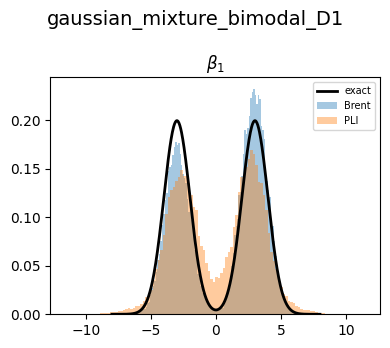

In [6]:
# ── 3. Bimodal mixture D=1 ──
print("\n" + "="*60)
print("TEST 3: Bimodal mixture D=1")
print("="*60)
target_mix = make_gaussian_mixture(D=1, preset="bimodal")

samp_mix_brent = run_test(target_mix, thinning="brent",
                    N_skeleton=N_SKELETON, N_resample=N_RESAMPLE,
                    refresh_rate=1.0)

samp_mix_pli = run_test(target_mix, thinning="pli",
                    N_skeleton=N_SKELETON, N_resample=N_RESAMPLE,
                    refresh_rate=1.0)
plot_marginals(target_mix, {"Brent":samp_mix_brent, "PLI": samp_mix_pli})


TEST 4: Banana D=2, a=1, scale=1


Boomerang: 100%|██████████| 10000/10000 [00:26<00:00, 378.97skel/s, t=5612.903]



=== Sampler Diagnostics ===
Total gradient evals  : 621985
Grad evals / skeleton : 62.2

=== Thinning ===
Accept / Reject  : 4391 / 12539

=== Event breakdown ===
  bounce    : 16930 events, mean horizon=0.8098
  no_event  :  7090 events, mean horizon=0.4721
  refresh   :  5608 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000877
Total wall-sec       : 25.99

Simulation time reached: 5612.9029


Boomerang: 100%|██████████| 10000/10000 [00:03<00:00, 2593.30skel/s, t=6802.981]



=== Sampler Diagnostics ===
Total gradient evals  : 60541
Grad evals / skeleton : 6.1

=== Thinning ===
Bound violations : 195
Max ratio        : 1.4973
Proposals/call   : 0.4 mean, 11 max
Accepted bounces : 3196

=== Event breakdown ===
  bounce    :  3196 events, mean horizon=1.5199
  no_event  :  6803 events, mean horizon=0.7647
  refresh   :  6803 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000210
Total wall-sec       : 3.53

Simulation time reached: 6802.9807


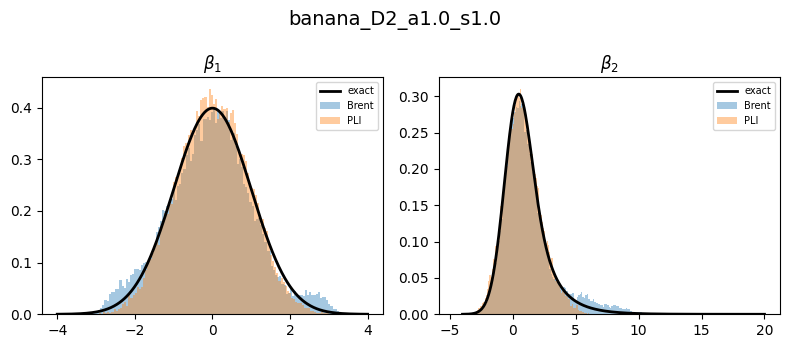


All smoke tests complete.


In [7]:
# ── 4. Banana D=2 ──
print("\n" + "="*60)
print("TEST 4: Banana D=2, a=1, scale=1")
print("="*60)
target_ban = make_banana(D=2, a=1.0, scale=1.0)

samp_ban_brent = run_test(target_ban, thinning="brent",
                    N_skeleton=N_SKELETON, N_resample=N_RESAMPLE,
                    refresh_rate=1.0)

samp_ban_pli = run_test(target_ban, thinning="pli",
                    N_skeleton=N_SKELETON, N_resample=N_RESAMPLE,
                    refresh_rate=1.0)
plot_marginals(target_ban, {"Brent":samp_ban_brent, "PLI": samp_ban_pli})

print("\nAll smoke tests complete.")

## TEST WARMUP


TEST: Banana D=2, a=1, scale=1


Boomerang: 100%|██████████| 10000/10000 [01:00<00:00, 164.16skel/s, t=16077.756]



=== Sampler Diagnostics ===
Total gradient evals  : 1025921
Grad evals / skeleton : 102.6

=== Thinning ===
Accept / Reject  : 8370 / 20371

=== Event breakdown ===
  bounce    : 28741 events, mean horizon=0.9811
  no_event  : 10860 events, mean horizon=0.9126
  refresh   :  1629 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.001470
Total wall-sec       : 60.61

Simulation time reached: 16077.7558


Boomerang: 100%|██████████| 10000/10000 [00:10<00:00, 988.14skel/s, t=52114.692]



=== Sampler Diagnostics ===
Total gradient evals  : 67696
Grad evals / skeleton : 6.8

=== Thinning ===
Bound violations : 700
Max ratio        : 1.4938
Proposals/call   : 0.8 mean, 11 max
Accepted bounces : 4829

=== Event breakdown ===
  bounce    :  4829 events, mean horizon=10.7869
  no_event  :  5170 events, mean horizon=9.1402
  refresh   :  5170 events, mean horizon=0.0000

=== Timing ===
Mean wall-sec / iter : 0.000627
Total wall-sec       : 9.51

Simulation time reached: 52114.6924


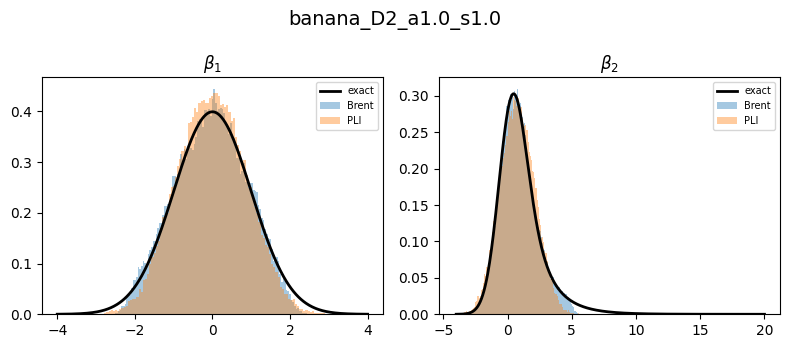

In [8]:
from sazz.samplers.AutomaticBoomerangSampler import AutomaticBoomerangSampler
from sazz.utils.warmup import warmup
from sazz.utils.sampling import resample_pdmp_path
from sazz.models.smoke_test import make_banana

N_SKELETON = 10_000
N_RESAMPLE = 100_000

print("\n" + "=" * 60)
print("TEST: Banana D=2, a=1, scale=1")
print("=" * 60)

target_ban = make_banana(D=2, a=1.0, scale=1.0)

# --- Brent ---
sampler_brent = AutomaticBoomerangSampler(
    grad_target=target_ban.grad_target,
    D=target_ban.D,
    refresh_rate=0.1,
    thinning="brent",
)
warmup(sampler_brent, n_rounds=3, n_pilot=500, target=target_ban)
result_brent = sampler_brent.sample(N=N_SKELETON, diagnostics=True)

samples_brent = resample_pdmp_path(
    result_brent["positions"].cpu().numpy(),
    result_brent["velocities"].cpu().numpy(),
    result_brent["times"].cpu().numpy(),
    sampler_brent.x_ref.cpu().numpy(),
    N_resample=N_RESAMPLE,
)

# --- PLI ---
sampler_pli = AutomaticBoomerangSampler(
    grad_target=target_ban.grad_target,
    D=target_ban.D,
    refresh_rate=0.1,
    thinning="pli",
)
warmup(sampler_pli, n_rounds=3, n_pilot=500, target=target_ban)
result_pli = sampler_pli.sample(N=N_SKELETON, diagnostics=True)

samples_pli = resample_pdmp_path(
    result_pli["positions"].cpu().numpy(),
    result_pli["velocities"].cpu().numpy(),
    result_pli["times"].cpu().numpy(),
    sampler_pli.x_ref.cpu().numpy(),
    N_resample=N_RESAMPLE,
)

# --- Plot ---
plot_marginals(target_ban, {"Brent": samples_brent, "PLI": samples_pli})